https://chatgpt.com/c/69ce0c9e-32e4-8325-854f-4dd731364874

# GOED

In [6]:
import tensorflow as tf
from tensorflow import keras
from kerastuner.tuners import Hyperband
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

# GOED

In [7]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data
y = data.target

# train+val en test (90%/10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# train en val (70%/20% van 90%) ongveer 20%, niet exact
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.22, random_state=42)

norm_layer = keras.layers.Normalization()
norm_layer.adapt(X_train)

# eventueel parameters aanpassen

In [8]:
# --- 2. Modelbuilder functie ---
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=X_train.shape[1:]))
    model.add(norm_layer)
    for i in range(hp.Int('num_layers', 3, 10)):
        model.add(
            keras.layers.Dense(
                units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32),
                activation=hp.Choice('activation', ['relu', 'tanh'])
            )
        )
    
    model.add(keras.layers.Dense(1))  # outputlaag voor regressie

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-5, 1e-4, 1e-3, 1e-2])
        ),
        loss='mse', # wat hij gaat proberen verminderen
        metrics=['mse', 'RootMeanSquaredError'] # dit is puur voor visueel zodat je kan interpreteren hoe het model presteert
    )
    
    return model

# max trials? objective? num_initial_points?

In [ ]:
# --- 3. Bayesian Optimization Tuner ---
tuner = Hyperband(
    build_model,
    objective='val_mse',
    max_epochs=200,  # maximale epochs per voor de laatste trial
    factor=2,         # bepaalt hoeveel modellen overleven elke halveringsstap
    directory='../Bachelorproef_modellen/MLP_hyp',
    project_name='MLP_hyper_opt'
)

# eventueel patience, batch_size

In [11]:
# --- 4. Start hyperparameter tuning ---
early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # validatie MSE
    patience=10,
    min_delta=0.001,         # kleine verbetering in MAE is al goed
    restore_best_weights=True,
    mode='min'               # MAE moet omlaag
)

tuner.search(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    batch_size=32, # batch_size=hp.Choice('batch_size', [16, 32, 64]) ?
    callbacks=[early_stopping_cb],
    verbose=1
)

Trial 1114 Complete [00h 00m 59s]
val_mse: 0.29584887623786926

Best val_mse So Far: 0.25349071621894836
Total elapsed time: 11h 02m 14s

Search: Running Trial #1115

Value             |Best Value So Far |Hyperparameter
10                |5                 |num_layers
192               |384               |units_0
relu              |tanh              |activation
384               |320               |units_1
224               |480               |units_2
1e-05             |0.0001            |learning_rate
416               |384               |units_3
352               |96                |units_4
160               |480               |units_5
288               |160               |units_6
416               |384               |units_7
320               |480               |units_8
256               |352               |units_9
16                |250               |tuner/epochs
0                 |125               |tuner/initial_epoch
5                 |6                 |tuner/bracket
0        

KeyboardInterrupt: 

# GOED

In [12]:
# --- 5. Beste hyperparameters en model ---
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Beste hyperparameters:")
print(best_hp.values)

best_model = tuner.get_best_models(1)[0]

Beste hyperparameters:
{'num_layers': 5, 'units_0': 384, 'activation': 'tanh', 'units_1': 320, 'units_2': 480, 'learning_rate': 0.0001, 'units_3': 384, 'units_4': 96, 'units_5': 480, 'units_6': 160, 'units_7': 384, 'units_8': 480, 'units_9': 352, 'tuner/epochs': 250, 'tuner/initial_epoch': 125, 'tuner/bracket': 6, 'tuner/round': 5, 'tuner/trial_id': '1068'}


In [13]:
best_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 8)                 17        
 on)                                                             
                                                                 
 dense (Dense)               (None, 384)               3456      
                                                                 
 dense_1 (Dense)             (None, 320)               123200    
                                                                 
 dense_2 (Dense)             (None, 480)               154080    
                                                                 
 dense_3 (Dense)             (None, 384)               184704    
                                                                 
 dense_4 (Dense)             (None, 96)                36960     
                                                        

In [14]:
results = best_model.evaluate(X_test, y_test)
print(f"general loss: {results[0]}")
print(f"general mse: {results[1]}")
print(f"general rmse: {results[2]}")

65/65 [==============================] - 1s 5ms/step - loss: 0.2573 - mse: 0.2573 - root_mean_squared_error: 0.5072
general loss: 0.25727662444114685
general mse: 0.25727662444114685
general rmse: 0.507224440574646


128/128 [==============================] - 1s 5ms/step
Training:  15.178879%
Validatie:  17.64%
MAE: 0.33
RMSE: 0.51
MAPE: 17.70%
R²: 0.81


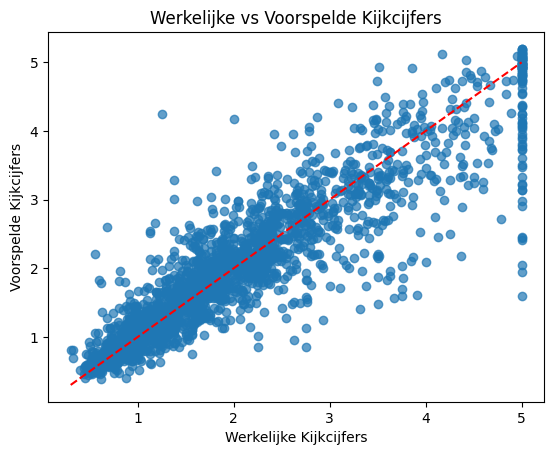

In [15]:
best_model = tuner.get_best_models(1)[0]
# pipeline = onehote encoding, standardizing, decisiontree training ---> trainingsdata
predictions = best_model.predict(X_test)
# pipeline = onehote encoding, standardizing, decisiontree voorspel ---> input

# testen op under en overfitting
train_predictions = best_model.predict(X_train)
val_predictions = best_model.predict(X_val)
print(f"Training:  {mean_absolute_percentage_error(y_train, train_predictions):2%}")
print(f"Validatie:  {mean_absolute_percentage_error(y_val, val_predictions):.2%}")


# Evaluatie
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"R²: {r2:.2f}")

# Visualiseer en interpreteer je resultaten.
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Werkelijke Kijkcijfers')
plt.ylabel('Voorspelde Kijkcijfers')
plt.title('Werkelijke vs Voorspelde Kijkcijfers')
plt.show()

# EXPERIMENTEN

In [31]:
X_new = X_test[:3]  # pretend these are new instances
y_proba = best_model.predict(X_new)
print(y_test[:3][0], y_test[:3][1], y_test[:3][2])
print(y_proba[0][0].round(3), y_proba[1][0].round(3), y_proba[2][0].round(3))

1/1 [==============================] - 0s 18ms/step
0.477 0.458 5.00001
0.489 0.75 4.804
